# Figure S2: Stacked ROI Pulse Detections Across Recording Nights

This notebook loads the filtered in-ROI, persistence-filtered detection CSVs from the four per-video analysis notebooks and plots them with a shared time axis.

Features:
- Common x-axis (seconds since start of each video).
- Uniform y-axis limit across all panels (max count observed).
- One subplot per video, stacked vertically, sharing the x-axis.
- Per-region line plots (excluding 'outside').
- Moonrise vertical line specific to each video (offset from video start).

Adjust configuration in the first code cell if needed (e.g., bin size, moonrise offsets, start clocks).

In [1]:
# Configuration: list of videos and their moonrise offsets (H:MM or HH:MM)
# Video stems MUST match the processed filtered CSV naming pattern: <stem>_streaks_in_roi_filtered.csv
videos = [
    'GX010063_2025Nov10',
    'GX010067_2025Nov12',
    'GX010072_2025Nov13',
    'GX01007X_2025Nov14'
]

# Moonrise offsets extracted from individual notebooks (offset from start clock)
moonrise_offsets = {
    'GX010063_2025Nov10': '4:30',
    'GX010067_2025Nov12': '5:24',
    'GX010072_2025Nov13': '6:14',
    'GX01007X_2025Nov14': '7:01',
}

# Global start clock (display baseline for x-axis labels)
START_CLOCK = '19:00'  # x-axis zero seconds will be labeled 19:00

# Optional: start clock labels per video (for title context)
start_clocks = {
    'GX010063_2025Nov10': START_CLOCK,
    'GX010067_2025Nov12': START_CLOCK,
    'GX010072_2025Nov13': START_CLOCK,
    'GX01007X_2025Nov14': START_CLOCK,
}

# Time bin size (seconds) for aggregation.
BIN_SECONDS = 60.0

# Path setup
from pathlib import Path
ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
FIGURES_DIR = ROOT / 'figures' / 'supplemental'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Videos:', videos)
print('Moonrise offsets:', moonrise_offsets)
print('Start clock baseline:', START_CLOCK)
print('Bin size (s):', BIN_SECONDS)

Videos: ['GX010063_2025Nov10', 'GX010067_2025Nov12', 'GX010072_2025Nov13', 'GX01007X_2025Nov14']
Moonrise offsets: {'GX010063_2025Nov10': '4:30', 'GX010067_2025Nov12': '5:24', 'GX010072_2025Nov13': '6:14', 'GX01007X_2025Nov14': '7:01'}
Start clock baseline: 19:00
Bin size (s): 60.0


In [2]:
# Utility functions
import math, json, io
import importlib.util
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker as mticker
from matplotlib.patches import FancyBboxPatch
from pathlib import Path

# Load shared plotting style + palette used across figure notebooks.
style_dir_candidates = [
    ROOT / 'notebooks' / 'styles',
    Path.cwd() / 'styles',
    Path.cwd() / '..' / 'notebooks' / 'styles',
]

style_dir = next(
    (
        p.resolve()
        for p in style_dir_candidates
        if (p / 'photeros.mplstyle').exists() and (p / 'figure_style.py').exists()
    ),
    None,
)

if style_dir is None:
    raise FileNotFoundError('Could not find shared style files in notebooks/styles')

style_path = style_dir / 'photeros.mplstyle'
module_path = style_dir / 'figure_style.py'

spec = importlib.util.spec_from_file_location('figure_style_shared', module_path)
figure_style = importlib.util.module_from_spec(spec)
spec.loader.exec_module(figure_style)

figure_style.apply_photeros_style(style_path)
palette = figure_style.get_palette()

print(f'Shared style loaded from: {style_path}')

# Parse HH:MM or H:MM style offsets
def parse_moonrise_offset(s: str) -> int:
    parts = s.strip().split(':')
    if len(parts) < 2:
        raise ValueError(f'Invalid moonrise offset: {s}')
    h = int(parts[0]); m = int(parts[1]); return h*3600 + m*60

# Parse global START_CLOCK (already set in config cell) for label baseline
def parse_start_clock(s: str) -> int:
    parts = s.strip().split(':')
    if len(parts) < 2:
        raise ValueError(f'Invalid START_CLOCK: {s}')
    h = int(parts[0]) % 24; m = int(parts[1]); sec = int(parts[2]) if len(parts) > 2 else 0
    return h*3600 + m*60 + sec

_start_clock_offset = parse_start_clock(START_CLOCK)

# Formatter adding baseline so 0 seconds -> START_CLOCK (e.g., 19:00)
def hhmm_formatter_factory():
    def _fmt(x, pos):
        total_seconds = float(x) + _start_clock_offset
        hours = int((total_seconds // 3600) % 24)
        minutes = int((total_seconds % 3600) // 60)
        return f'{hours:02d}:{minutes:02d}'
    return _fmt

# Load filtered counts pivot per video
def load_filtered_counts(stem: str, bin_seconds: float) -> pd.DataFrame:
    csv_path = PROCESSED_DIR / f'{stem}_streaks_in_roi_filtered.csv'
    if not csv_path.exists():
        raw = PROCESSED_DIR / f'{stem}_streaks.csv'
        if not raw.exists():
            raise FileNotFoundError(f'Neither filtered nor raw CSV found for video stem {stem}')
        with open(raw, 'r') as f:
            lines = f.readlines()
        header_idx = next((i for i,l in enumerate(lines[:100]) if l.lower().startswith('frame,')), 0)
        df = pd.read_csv(io.StringIO(''.join(lines[header_idx:])))
        print(f'[WARN] Using RAW CSV (not filtered) for {stem}')
    else:
        with open(csv_path, 'r') as f:
            lines = f.readlines()
        header_idx = next((i for i,l in enumerate(lines[:100]) if l.lower().startswith('frame,')), 0)
        df = pd.read_csv(io.StringIO(''.join(lines[header_idx:])))
    if 'region' not in df.columns:
        raise ValueError(f'CSV for {stem} missing region column')
    dfi = df[df['region'] != 'outside'].copy()
    if dfi.empty:
        return pd.DataFrame(columns=['time_bin'])
    dfi['time_bin'] = (dfi['time_s'] // bin_seconds) * bin_seconds
    counts = dfi.groupby(['region','time_bin']).size().reset_index(name='count')
    pivot = counts.pivot(index='time_bin', columns='region', values='count').fillna(0)
    start_bin = float(pivot.index.min()) if len(pivot.index) else 0.0
    end_bin = float(pivot.index.max()) if len(pivot.index) else 0.0
    all_bins = np.arange(start_bin, end_bin + bin_seconds, bin_seconds, dtype=float)
    pivot = pivot.reindex(all_bins, fill_value=0)
    pivot.index.name = 'time_bin'
    return pivot

# Aggregate across videos
all_counts = {}
all_regions = set()
global_ymax = 0
for stem in videos:
    pivot = load_filtered_counts(stem, BIN_SECONDS)
    all_counts[stem] = pivot
    all_regions.update(pivot.columns.tolist())
    if not pivot.empty:
        local_max = pivot.max().max()
        global_ymax = max(global_ymax, local_max)
    print(f'Loaded {stem}: shape={pivot.shape}, local_max={pivot.max().max() if not pivot.empty else 0}')

print('All regions union:', sorted(all_regions))
print('Global y-axis max:', global_ymax)

Shared style loaded from: /Users/oakley/Documents/GitHub/signal_respirometry/notebooks/styles/photeros.mplstyle
Loaded GX010063_2025Nov10: shape=(161, 3), local_max=54.0
Loaded GX010067_2025Nov12: shape=(711, 3), local_max=22.0
Loaded GX010072_2025Nov13: shape=(719, 3), local_max=13.0
Loaded GX01007X_2025Nov14: shape=(710, 2), local_max=27.0
All regions union: ['left', 'middle', 'right', 'roi_1', 'roi_2']
Global y-axis max: 54.0


Saved stacked comparison figure to /Users/oakley/Documents/GitHub/signal_respirometry/figures/supplemental/FigureS2_AllVideosComparison.pdf


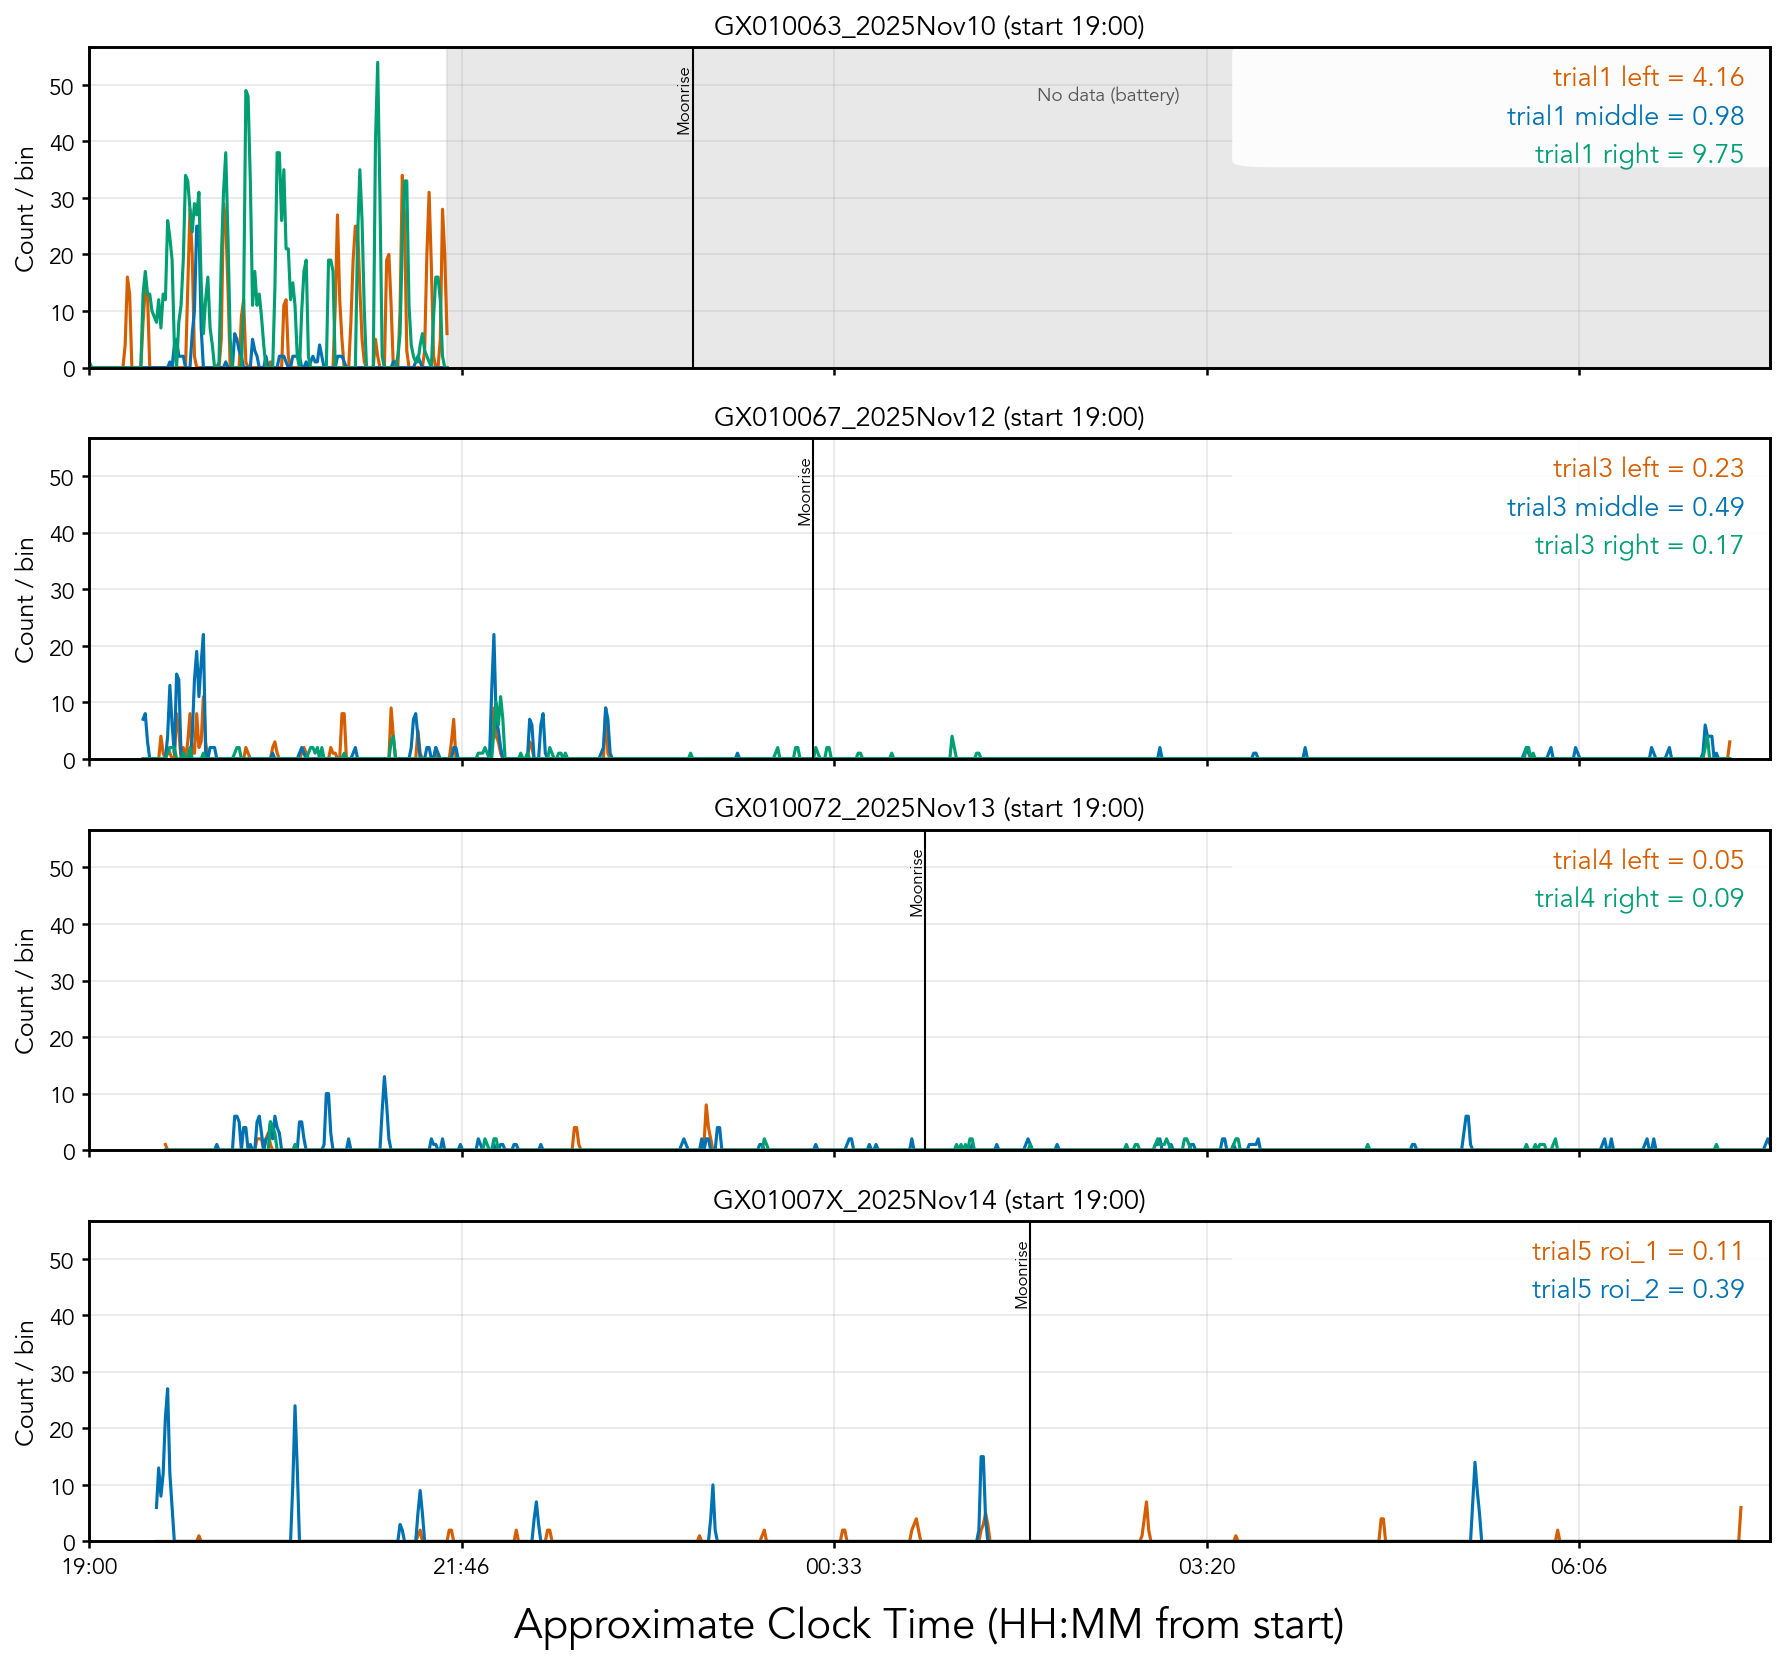

In [3]:
# Plot stacked panels
if not all_counts:
    raise RuntimeError('No data loaded to plot.')

fig, axes = plt.subplots(len(videos), 1, figsize=(12, 2.8*len(videos)), sharex=True)
if len(videos) == 1:
    axes = [axes]  # ensure iterable list when single subplot

moonrise_seconds = {stem: parse_moonrise_offset(moonrise_offsets.get(stem, '0:00')) for stem in videos}

# Map each recording night to trial label for rate legend text.
night_to_trial = {
    '2025Nov10': 'trial1',
    '2025Nov12': 'trial3',
    '2025Nov13': 'trial4',
    '2025Nov14': 'trial5',
}

# Exclude the unmatched Nov13 middle replicate so this plot aligns with Figure 3 supplemental keys.
excluded_rate_label_keys = {
    ('2025Nov13', 'middle'),
}

# Use shared project palette for consistent figure styling.
region_colors = {
    'left': palette['dark_orange'],
    'middle': palette['dark_blue'],
    'right': palette['teal'],
    'roi_1': palette['dark_orange'],
    'roi_2': palette['dark_blue'],
}

# Common x-range: union of all time bins (each starts at 0; extend to max duration among videos)
max_end = 0.0
for stem, pivot in all_counts.items():
    if not pivot.empty:
        max_end = max(max_end, float(pivot.index.max()))

fmt = mticker.FuncFormatter(hhmm_formatter_factory())

for ax, stem in zip(axes, videos):
    pivot = all_counts[stem]
    has_data = not pivot.empty
    if not has_data:
        ax.text(0.5, 0.5, f'No in-ROI detections for {stem}', ha='center', va='center')
        ax.set_ylim(0, 1)
    else:
        # Plot each region present in this pivot using fixed colors when available.
        for region in pivot.columns:
            ax.plot(
                pivot.index.values,
                pivot[region].values,
                label=region,
                color=region_colors.get(str(region).lower(), None),
            )
        ax.set_ylim(0, global_ymax * 1.05 if global_ymax > 0 else 1)

        # Moonrise line
        mr = moonrise_seconds.get(stem, 0)
        if 0 <= mr <= max_end:
            ax.axvline(mr, color='k', linestyle='-', linewidth=1.0)
            ax.text(mr, ax.get_ylim()[1]*0.95, 'Moonrise', rotation=90, va='top', ha='right', fontsize=8, color='k')

        # Build one shared white legend panel per subplot for rate text.
        night = stem.split('_')[-1]
        trial_label = night_to_trial.get(night, night)
        rate_lines = []
        for region in pivot.columns:
            region_name = str(region)
            if (night, region_name) in excluded_rate_label_keys:
                continue
            avg_rate = float(pivot[region].mean())
            label_text = f'{trial_label} {region_name} = {avg_rate:.2f}'
            label_color = region_colors.get(region_name.lower(), 'black')
            rate_lines.append((label_text, label_color))

        if rate_lines:
            panel_left = 0.70
            panel_right = 0.995
            panel_top = 0.985
            line_step = 0.12
            first_line_y = panel_top - 0.04
            panel_bottom = first_line_y - line_step * (len(rate_lines) - 1) - 0.06

            panel = FancyBboxPatch(
                (panel_left, panel_bottom),
                panel_right - panel_left,
                panel_top - panel_bottom,
                transform=ax.transAxes,
                boxstyle='round,pad=0.02',
                facecolor='white',
                edgecolor='none',
                alpha=0.9,
                zorder=2,
            )
            ax.add_patch(panel)

            y_text = first_line_y
            for label_text, label_color in rate_lines:
                ax.text(
                    panel_right - 0.01,
                    y_text,
                    label_text,
                    transform=ax.transAxes,
                    ha='right',
                    va='top',
                    fontsize=13,
                    color=label_color,
                    zorder=3,
                )
                y_text -= line_step

    ax.grid(alpha=0.3)
    clock_label = start_clocks.get(stem, '')
    ax.set_title(f'{stem} (start {clock_label})')
    ax.set_ylabel('Count / bin')
    ax.xaxis.set_major_formatter(fmt)
    ax.set_xlim(0, max_end)

    # Special styling for first video panel: keep data region white, shade missing battery section only
    if stem == videos[0] and has_data:
        last_bin = float(pivot.index.max()) if len(pivot.index) else 0.0
        if last_bin < max_end:
            # Shade only the missing segment (battery died)
            ax.axvspan(last_bin, max_end, color='lightgrey', alpha=0.5)
            mid_x = (last_bin + max_end) / 2.0
            ax.text(mid_x, ax.get_ylim()[1]*0.85, 'No data (battery)', ha='center', va='center', fontsize=9, color='#555')

axes[-1].set_xlabel('Approximate Clock Time (HH:MM from start)', fontsize=20, labelpad=12)
plt.tight_layout()
out_path = FIGURES_DIR / 'FigureS2_AllVideosComparison.pdf'
plt.savefig(out_path, bbox_inches='tight')
print('Saved stacked comparison figure to', out_path)
plt.show()

In [4]:
# --- Compute average signaling rate per position for each night/video ---

# Prepare results list
signal_rate_rows = []

for stem in videos:
    # Extract night/date from video stem (customize as needed)
    # Example: 'GX010063_2025Nov10' -> '2025Nov10'
    night = stem.split('_')[-1]
    pivot = all_counts[stem]
    if pivot.empty:
        continue
    # For each region/position (excluding 'outside' if present)
    for position in pivot.columns:
        if position.lower() == 'outside':
            continue
        # Average count per time bin (signal rate per bin)
        avg_rate = pivot[position].mean()
        signal_rate_rows.append({
            'night': night,
            'position': position,
            'signal_rate': avg_rate
        })

# Create DataFrame
signal_rate_df = pd.DataFrame(signal_rate_rows)
display(signal_rate_df)

,night,position,signal_rate
0,2025Nov10,left,4.161491
1,2025Nov10,middle,0.981366
2,2025Nov10,right,9.745342
3,2025Nov12,left,0.233474
4,2025Nov12,middle,0.485232
5,2025Nov12,right,0.174402
6,2025Nov13,left,0.051460
7,2025Nov13,middle,0.328234
8,2025Nov13,right,0.087622
9,2025Nov14,roi_1,0.108451


In [5]:
# --- Add manual metadata for combining with respirometry data ---

# Define manual metadata mapping for each (night, position)
metadata_map = {
    # Format: (night, position): {metadata fields}
    ('2025Nov10', 'left'):   {'trial': 'trial1', 'brick': 'box3', 'channel': 'Ch4'},
    ('2025Nov10', 'middle'): {'trial': 'trial1', 'brick': 'box3', 'channel': 'Ch3'},
    ('2025Nov10', 'right'):  {'trial': 'trial1', 'brick': 'box3', 'channel': 'Ch2'},

    ('2025Nov12', 'left'):   {'trial': 'trial3', 'brick': 'box2', 'channel': 'Ch4'},
    ('2025Nov12', 'middle'): {'trial': 'trial3', 'brick': 'box2', 'channel': 'Ch3'},
    ('2025Nov12', 'right'):  {'trial': 'trial3', 'brick': 'box2', 'channel': 'Ch2'},

#Hereon down I am assuming cylinders were in the same positions, not noted in field notes
    ('2025Nov13', 'left'):   {'trial': 'trial4', 'brick': 'newbox', 'channel': 'Ch4'},
    ('2025Nov13', 'right'):  {'trial': 'trial4', 'brick': 'newbox', 'channel': 'Ch2'},

#Here, there were only 2 Regions of interest and I am not sure of their left/right designation
#This is just a guess
#This didn't match Channel3, so I changed to Ch2, which I think is correct, but I did not fully confirm

    ('2025Nov14', 'roi_1'): {'trial': 'trial5', 'brick': 'box2', 'channel': 'Ch4'},
    ('2025Nov14', 'roi_2'): {'trial': 'trial5', 'brick': 'box2', 'channel': 'Ch2'},

}

# Apply metadata to the table
def add_metadata(row):
    key = (row['night'], row['position'])
    meta = metadata_map.get(key, {})
    for k, v in meta.items():
        row[k] = v
    return row

signal_rate_df = signal_rate_df.apply(add_metadata, axis=1)

# Keep only rows that map to known trial/brick/channel combinations used downstream.
pre_filter_n = len(signal_rate_df)
signal_rate_df = signal_rate_df.dropna(subset=['trial', 'brick', 'channel']).copy()
print(f'Retained {len(signal_rate_df)} of {pre_filter_n} rows after metadata key filtering.')

display(signal_rate_df)

# Save the signal rate table as a CSV for use in other notebooks
out_csv = PROCESSED_DIR / "signal_rate_summary.csv"
signal_rate_df.to_csv(out_csv, index=False)
print(f"Signal rate summary saved to: {out_csv}")

Retained 10 of 11 rows after metadata key filtering.


,brick,channel,night,position,signal_rate,trial
0,box3,Ch4,2025Nov10,left,4.161491,trial1
1,box3,Ch3,2025Nov10,middle,0.981366,trial1
2,box3,Ch2,2025Nov10,right,9.745342,trial1
3,box2,Ch4,2025Nov12,left,0.233474,trial3
4,box2,Ch3,2025Nov12,middle,0.485232,trial3
5,box2,Ch2,2025Nov12,right,0.174402,trial3
6,newbox,Ch4,2025Nov13,left,0.051460,trial4
8,newbox,Ch2,2025Nov13,right,0.087622,trial4
9,box2,Ch4,2025Nov14,roi_1,0.108451,trial5
10,box2,Ch2,2025Nov14,roi_2,0.391549,trial5


Signal rate summary saved to: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/signal_rate_summary.csv
